# PANORAMA baseline — inferenza PDAC + segmentazione + embedding  (v3)

> **Differenza rispetto al notebook originale:** una sola aggiunta, al punto **4-bis**, che salva
> anche la segmentazione a 7 classi **e l'embedding del bottleneck**. Il codice che produce punteggio, mappa di detection, AUROC e AP
> **non è stato toccato**: AUROC e AP sono identici alla v1.


Questo notebook prende esami TC addominali **con contrasto, fase porto-venosa** (`.nii.gz`)
e per ognuno restituisce un **punteggio 0–1**: quanto è probabile che il paziente abbia un
adenocarcinoma duttale del pancreas (PDAC).

Con quei punteggi calcola poi **AUROC** (diagnosi paziente) e, se hai le segmentazioni
manuali del tumore, anche **AP** (localizzazione della lesione).

## Come funziona (due reti in fila)

| | Cosa fa | Rete |
|---|---|---|
| **Stadio 1** | trova il pancreas su una versione a bassa risoluzione | nnU-Net, 2 classi |
| *in mezzo* | ritaglia una scatola attorno al pancreas (margine 100×50×15 mm) | pura geometria |
| **Stadio 2** | dentro la scatola segmenta 6 strutture, tumore incluso | nnU-Net, 7 classi (con lo sfondo) |
| *alla fine* | dalla mappa del tumore estrae le lesioni candidate; il **massimo** è il punteggio del paziente | post-processing |

> **Importante:** i modelli ricevono **solo l'immagine TC**. Le segmentazioni manuali,
> se le hai, servono unicamente a *valutare* i risultati — non entrano mai nel modello.

## Fonti (codice riprodotto fedelmente)

- Codice: <https://github.com/DIAGNijmegen/PANORAMA_baseline> (Apache-2.0)
- Pesi: <https://zenodo.org/records/11160381> (CC BY-NC 4.0 — **solo uso non commerciale**)
- Articolo: Alves N, Schuurmans M, Rutkowski D, et al. *Lancet Oncol* 2026;27(1):116–124

⚠️ **Strumento di ricerca**, non un dispositivo medico approvato. Non usare per decisioni cliniche.

---
## 1 · Configurazione

**È l'unica cella che devi modificare.** Tutto il resto gira da solo.

### Come organizzare i dati

```
CARTELLA_DATI/
├── PDAC/
│   ├── images/          ← TC dei pazienti CON tumore   (.nii.gz)
│   └── labels/          ← (opzionale) segmentazioni manuali del tumore
└── health/
    └── images/          ← TC dei controlli SENZA tumore (.nii.gz)
```

I nomi dei file devono corrispondere tra `images/` e `labels/` (es. `001.nii.gz` in entrambe).

In [1]:
from pathlib import Path

# ============================================================================
#  DOVE SIAMO  —  rilevato da solo, non serve toccarlo
# ============================================================================
# BASE_DIR = la cartella che contiene questo notebook (`baseline_pdac`).
# Usiamo percorsi RELATIVI, così l'intera cartella si può copiare su un altro
# computer (es. il Linux con GPU) e funziona senza modifiche.
#
# Il riconoscimento si basa su un file che c'è SEMPRE (questo notebook), non sulla
# cartella `models`: quest'ultima non esiste prima di aver scaricato i pesi, e usarla
# come riferimento renderebbe impossibile il primo avvio.
_MARKER = "panorama_baseline_inference.ipynb"
BASE_DIR = Path.cwd()
if not (BASE_DIR / _MARKER).exists():
    if (BASE_DIR / "baseline_pdac" / _MARKER).exists():
        BASE_DIR = BASE_DIR / "baseline_pdac"      # lanciato dalla cartella superiore
    else:
        print(f"ATTENZIONE: non trovo '{_MARKER}' in {BASE_DIR}.\n"
              f"            Se i percorsi non funzionano, imposta BASE_DIR a mano qui sotto.")

MODELS_DIR = BASE_DIR / "models"                 # pesi scaricati da Zenodo
OUTPUT_DIR = BASE_DIR / "risultati"              # punteggi e mappe di detection

# ============================================================================
#  I TUOI DATI  —  modifica questi
# ============================================================================
# Metti None se un gruppo non ce l'hai. Accetta percorsi assoluti o relativi.
# PDAC_IMAGES   = None    # es. Path("/percorso/PDAC/images")
# PDAC_LABELS   = None    # es. Path("/percorso/PDAC/labels")   -> serve solo per l'AP
# HEALTH_IMAGES = None    # es. Path("/percorso/health/images")

PDAC_IMAGES   = Path.home() / "Desktop/PhD_pancreas/panorama-inference/dati_tc/PDAC/images"
PDAC_LABELS   = Path.home() / "Desktop/PhD_pancreas/panorama-inference/dati_tc/PDAC/labels"
HEALTH_IMAGES = Path.home() / "Desktop/PhD_pancreas/panorama-inference/dati_tc/health/images"

# ============================================================================
#  OPZIONI DI ESECUZIONE
# ============================================================================
# "auto" sceglie la GPU se c'è, altrimenti la CPU
DEVICE = "auto"

# MODALITA' VELOCE: usa 1 fold e disattiva la TTA -> ~40x piu' rapido, ma i
# risultati NON sono identici a quelli ufficiali. Utile solo per provare che
# la pipeline funzioni. Per i risultati veri lascia False.
FAST_MODE = False

# Fedeltà massima (impostazioni ufficiali del baseline): 5 fold + TTA attiva
FOLDS    = (0,) if FAST_MODE else (0, 1, 2, 3, 4)
USE_TTA  = not FAST_MODE

# Salva le mappe di detection 3D (servono per calcolare l'AP)
SAVE_DETECTION_MAPS = True

# Se un caso è già stato processato, saltalo (permette di riprendere)
RESUME = False

print("Configurazione caricata.")
print(f"  modelli : {MODELS_DIR}")
print(f"  output  : {OUTPUT_DIR}")
print(f"  fold    : {FOLDS}   TTA: {USE_TTA}" + ("   [MODALITA' VELOCE]" if FAST_MODE else "   [fedeltà massima]"))

Configurazione caricata.
  modelli : /home/radiology/Desktop/PhD_pancreas/panorama-inference/baseline_pdac/models
  output  : /home/radiology/Desktop/PhD_pancreas/panorama-inference/baseline_pdac/risultati
  fold    : (0, 1, 2, 3, 4)   TTA: True   [fedeltà massima]


---
## 2 · Controllo dell'ambiente

Verifica che tutto sia installato e coerente. **Se qui compare un errore, fermati e
risolvilo** prima di andare avanti: gli errori a valle sarebbero molto più difficili da capire.

In [2]:
import sys, os, platform, shutil, warnings, time
warnings.filterwarnings("ignore", category=DeprecationWarning)

problemi = []

print("=" * 62)
print("AMBIENTE")
print("=" * 62)
print(f"  Python     : {sys.version.split()[0]}")
print(f"  Eseguibile : {sys.executable}")
print(f"  Sistema    : {platform.system()} {platform.machine()}")

# --- il kernel giusto? (l'ambiente puo' chiamarsi diversamente: controlliamo i pacchetti) ---
try:
    import nnunetv2 as _nn  # noqa: F401
except ImportError:
    problemi.append("nnunetv2 non è installato in QUESTO kernel: probabilmente hai selezionato "
                    "il kernel sbagliato (serve quello dell'ambiente con nnU-Net).")

import numpy as np
import torch
print(f"  NumPy      : {np.__version__}")
print(f"  PyTorch    : {torch.__version__}")

# --- numpy e torch devono essere compatibili ---
if int(np.__version__.split(".")[0]) >= 2 and torch.__version__ < "2.3":
    problemi.append(f"NumPy {np.__version__} non è compatibile con PyTorch {torch.__version__}: serve numpy<2.")

import nibabel, SimpleITK as sitk
print(f"  nibabel    : {nibabel.__version__}")
print(f"  SimpleITK  : {sitk.__version__}")

try:
    import nnunetv2
    print(f"  nnU-Net    : {nnunetv2.__version__ if hasattr(nnunetv2,'__version__') else 'installato'}")
except ImportError:
    problemi.append("nnunetv2 non installato.")

try:
    from report_guided_annotation import extract_lesion_candidates
    print("  report-guided-annotation : ok")
except ImportError:
    problemi.append("report-guided-annotation non installato.")

try:
    import openpyxl  # serve a pandas per leggere gli .xlsx (usato dal benchmark)
except ImportError:
    print("  openpyxl : assente (serve solo per il benchmark al punto 8)")

# --- torch >= 2.6 non riesce a caricare questi checkpoint ---
# dalla 2.6 `torch.load` usa weights_only=True di default e i checkpoint del
# baseline (che contengono oggetti numpy) vengono rifiutati.
_tv = tuple(int(x) for x in torch.__version__.split("+")[0].split(".")[:2])
if _tv >= (2, 6):
    problemi.append(f"PyTorch {torch.__version__} è troppo recente per nnunetv2 2.5.1: "
                    f"dalla 2.6 il caricamento dei checkpoint fallisce "
                    f"(weights_only=True). Usa torch < 2.6, es. 2.5.1.")

# --- device ---
if DEVICE == "auto":
    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
else:
    device = torch.device(DEVICE)
print(f"\n  Device     : {device}")
if device.type == "cuda":
    p = torch.cuda.get_device_properties(0)
    print(f"  GPU        : {p.name}  ({p.total_memory/1e9:.1f} GB)")
else:
    print("  ATTENZIONE : nessuna GPU -> inferenza su CPU, da 30 min a 2 h PER CASO.")
    print("               Va bene per provare su pochi casi; per lotti grandi serve una GPU.")

# --- il trainer personalizzato del baseline deve essere raggiungibile ---
try:
    import nnunetv2, os as _os
    _tdir = _os.path.join(nnunetv2.__path__[0], "training", "nnUNetTrainer")
    if not _os.path.exists(_os.path.join(_tdir, "customTrainerCEcheckpoints.py")):
        problemi.append("Manca 'customTrainerCEcheckpoints.py' dentro nnunetv2 (vedi SETUP_GUIDE.md).")
    else:
        print("  Trainer personalizzato del baseline : ok")
except Exception as e:
    problemi.append(f"Non riesco a controllare il trainer: {e}")

# --- spazio disco ---
if OUTPUT_DIR.parent.exists():
    free_gb = shutil.disk_usage(OUTPUT_DIR.parent).free / 1e9
    print(f"\n  Spazio libero : {free_gb:.1f} GB")
    if SAVE_DETECTION_MAPS and free_gb < 5:
        problemi.append(f"Solo {free_gb:.1f} GB liberi: le mappe di detection occupano spazio.")

print("\n" + "=" * 62)
if problemi:
    print("PROBLEMI DA RISOLVERE:")
    for p in problemi:
        print("   [X]", p)
    raise SystemExit("Sistema i problemi elencati prima di proseguire.")
print("AMBIENTE OK")
print("=" * 62)

AMBIENTE
  Python     : 3.12.13
  Eseguibile : /home/radiology/Desktop/PhD_pancreas/panorama-inference/.venv-nnunet/bin/python
  Sistema    : Linux x86_64
  NumPy      : 2.5.1
  PyTorch    : 2.5.1+cu121
  nibabel    : 5.4.2
  SimpleITK  : 2.5.5
  nnU-Net    : installato


Please cite the following paper when using Report Guided Annotations:

Bosma, J.S., et al. "Semi-supervised learning with report-guided lesion annotation for deep learning-based prostate cancer detection in bpMRI" to be submitted


If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/Report-Guided-Annotation

  report-guided-annotation : ok

  Device     : cuda
  GPU        : NVIDIA RTX A6000  (51.0 GB)
  Trainer personalizzato del baseline : ok

  Spazio libero : 48.6 GB

AMBIENTE OK


---
## 3 · I modelli ci sono?

Controlla che i pesi scaricati da Zenodo siano al loro posto e completi.
Se mancano, la cella stampa il comando esatto per scaricarli.

In [3]:
M_STAGE1 = MODELS_DIR / "Dataset103_PANORAMA_baseline_Pancreas_Segmentation" / "nnUNetTrainer__nnUNetPlans__3d_fullres"
M_STAGE2 = MODELS_DIR / "Dataset104_PANORAMA_baseline_PDAC_Detection" / "nnUNetTrainer_Loss_CE_checkpoints__nnUNetPlans__3d_fullres"
CK_STAGE1 = "checkpoint_final.pth"
CK_STAGE2 = "checkpoint_best_panorama.pth"

ISTRUZIONI = f"""
I pesi non ci sono. Scaricali (1,8 GB in totale) con:

  cd {MODELS_DIR.parent}
  mkdir -p {MODELS_DIR.name} && cd {MODELS_DIR.name}
  curl -L -o D103.zip "https://zenodo.org/records/11160381/files/Dataset103_PANORAMA_baseline_Pancreas_Segmentation.zip?download=1"
  curl -L -o D104.zip "https://zenodo.org/records/11160381/files/Dataset104_PANORAMA_baseline_PDAC_Detection.zip?download=1"
  unzip -q D103.zip && unzip -q D104.zip
"""

mancanti = []
for nome, folder, ck in [("Stadio 1", M_STAGE1, CK_STAGE1), ("Stadio 2", M_STAGE2, CK_STAGE2)]:
    if not folder.exists():
        mancanti.append(f"{nome}: cartella assente ({folder})")
        continue
    for f in FOLDS:
        p = folder / f"fold_{f}" / ck
        if not p.exists():
            mancanti.append(f"{nome}: manca {p.name} in fold_{f}")
    for j in ["plans.json", "dataset.json"]:
        if not (folder / j).exists():
            mancanti.append(f"{nome}: manca {j}")

if mancanti:
    for m in mancanti:
        print("  [X]", m)
    print(ISTRUZIONI)
    raise SystemExit("Modelli mancanti.")

tot = sum(f.stat().st_size for f in MODELS_DIR.rglob("*.pth")) / 1e6
print(f"  Modelli presenti e completi  ({tot:.0f} MB di pesi, fold richieste: {list(FOLDS)})")

  Modelli presenti e completi  (1893 MB di pesi, fold richieste: [0, 1, 2, 3, 4])


---
## 4 · La pipeline

Qui sotto c'è la traduzione fedele di `data_utils.py` e `process.py` del repo ufficiale.
Ogni funzione ha un commento che spiega **cosa fa e perché**.

Le uniche differenze rispetto all'originale, entrambe senza effetto sui risultati:

1. usiamo l'**API Python** di nnU-Net invece di lanciare `nnUNetv2_predict` come sottoprocesso;
2. lavoriamo **in memoria** invece di scrivere file temporanei a ogni passaggio.

In [4]:
import numpy as np
import SimpleITK as sitk
from scipy.ndimage import binary_dilation
from report_guided_annotation import extract_lesion_candidates
from nnunetv2.inference.predict_from_raw_data import nnUNetPredictor
from nnunetv2.imageio.simpleitk_reader_writer import SimpleITKIO

# Valori ufficiali del baseline: NON modificarli se vuoi risultati confrontabili
SPACING_STAGE1 = (4.5, 4.5, 9.0)   # risoluzione grossolana per lo stadio 1
CROP_MARGINS   = [100, 50, 15]     # margine in MILLIMETRI su x, y, z (per lato)
DILATION_KERNEL = np.ones((5, 5, 5), dtype=bool)


def resample_img(itk_image, out_spacing, is_label=False):
    """Ricampiona a una data risoluzione (identica a data_utils.resample_img)."""
    original_spacing = itk_image.GetSpacing()
    original_size = itk_image.GetSize()
    out_size = [int(np.round(original_size[i] * (original_spacing[i] / out_spacing[i]))) for i in range(3)]
    r = sitk.ResampleImageFilter()
    r.SetOutputSpacing(out_spacing)
    r.SetSize(out_size)
    r.SetOutputDirection(itk_image.GetDirection())
    r.SetOutputOrigin(itk_image.GetOrigin())
    r.SetTransform(sitk.Transform())
    r.SetDefaultPixelValue(itk_image.GetPixelIDValue())
    r.SetInterpolator(sitk.sitkNearestNeighbor if is_label else sitk.sitkBSpline)
    return r.Execute(itk_image)


def crop_pancreas_roi(image, low_res_segmentation, margins=CROP_MARGINS):
    """Ritaglia la scatola attorno al pancreas predetto.

    Prende il bounding box della maschera, lo allarga del margine (in mm, su
    ENTRAMBI i lati di ogni asse) e taglia l'immagine a piena risoluzione.
    Identica a data_utils.CropPancreasROI.
    """
    mask_np = sitk.GetArrayFromImage(low_res_segmentation)
    if mask_np.max() == 0:
        raise RuntimeError("Lo stadio 1 non ha trovato il pancreas: impossibile ritagliare.")

    nz = np.nonzero(mask_np)                      # array numpy in ordine (z, y, x)
    start_idx = (int(nz[2].min()), int(nz[1].min()), int(nz[0].min()))   # -> (x, y, z)
    finish_idx = (int(nz[2].max()), int(nz[1].max()), int(nz[0].max()))

    # dagli indici della maschera a bassa risoluzione alle coordinate fisiche,
    # e da queste agli indici dell'immagine ad alta risoluzione
    start_phys = low_res_segmentation.TransformIndexToPhysicalPoint(start_idx)
    finish_phys = low_res_segmentation.TransformIndexToPhysicalPoint(finish_idx)
    start_point = image.TransformPhysicalPointToIndex(start_phys)
    finish_point = image.TransformPhysicalPointToIndex(finish_phys)

    spacing, size = image.GetSpacing(), image.GetSize()
    m = [int(margins[i] / spacing[i]) for i in range(3)]   # margine mm -> voxel

    x0, x1 = max(0, start_point[0] - m[0]), min(size[0], finish_point[0] + m[0])
    y0, y1 = max(0, start_point[1] - m[1]), min(size[1], finish_point[1] + m[1])
    z0, z1 = max(0, start_point[2] - m[2]), min(size[2], finish_point[2] + m[2])

    cropped = image[x0:x1, y0:y1, z0:z1]
    coords = dict(x_start=x0, x_finish=x1, y_start=y0, y_finish=y1, z_start=z0, z_finish=z1)
    return cropped, coords


def post_processing(seg_stage2, probs_stage2):
    """Azzera la probabilità di tumore fuori dal pancreas (filtro anti-falsi-positivi).

    Ricostruisce la maschera del pancreas unendo le classi 1 (tumore), 4 (parenchima)
    e 5 (dotto), la dilata di un kernel 5x5x5 voxel e tiene la probabilità di tumore
    solo lì dentro. Identica a data_utils.PostProcessing.
    """
    pancreas = np.isin(seg_stage2, [1, 4, 5])
    dilated = binary_dilation(pancreas, structure=DILATION_KERNEL)
    tumor_prob = probs_stage2[1].astype(np.float32)   # canale 1 = tumore
    tumor_prob[~dilated] = 0
    return tumor_prob


def to_full_size(tumor_prob_cropped, coords, full_image):
    """Estrae le lesioni candidate e rimette la mappa nel volume originale.

    Restituisce (mappa di detection a dimensione piena, punteggio, n. candidati).
    Il punteggio è il MASSIMO della mappa. Identica a data_utils.GetFullSizDetectionMap.
    """
    lesion_candidates, confidences, _ = extract_lesion_candidates(tumor_prob_cropped)
    patient_score = float(np.max(lesion_candidates))

    # GetSize() e' (x, y, z), gli array numpy sono (z, y, x) -> invertiamo.
    # (usare GetArrayFromImage solo per leggere la forma sprecherebbe centinaia di MB)
    full_shape = full_image.GetSize()[::-1]
    full_map = np.zeros(full_shape, dtype=np.float32)
    full_map[coords["z_start"]:coords["z_finish"],
             coords["y_start"]:coords["y_finish"],
             coords["x_start"]:coords["x_finish"]] = lesion_candidates
    return full_map, patient_score, len(confidences)


print("Funzioni della pipeline definite.")

nnUNet_raw is not defined and nnU-Net can only be used on data for which preprocessed files are already present on your system. nnU-Net cannot be used for experiment planning and preprocessing like this. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up properly.
nnUNet_preprocessed is not defined and nnU-Net can not be used for preprocessing or training. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up.
nnUNet_results is not defined and nnU-Net cannot be used for training or inference. If this is not intended behavior, please read documentation/setting_up_paths.md for information on how to set this up.
Funzioni della pipeline definite.


### Caricamento dei due modelli

I modelli si caricano **una volta sola** e restano in memoria per tutti i casi
(caricarli a ogni esame sarebbe uno spreco di minuti).

In [5]:
def carica_predictor(model_folder, checkpoint, folds, device, use_tta):
    p = nnUNetPredictor(
        tile_step_size=0.5,          # sovrapposizione della finestra scorrevole (default ufficiale)
        use_gaussian=True,
        use_mirroring=use_tta,       # TTA: ribaltamenti speculari
        perform_everything_on_device=(device.type == "cuda"),
        device=device,
        verbose=False,
        allow_tqdm=False,
    )
    p.initialize_from_trained_model_folder(str(model_folder), use_folds=folds, checkpoint_name=checkpoint)
    return p


t0 = time.time()
print("Carico i modelli (una volta sola)...")
PRED1 = carica_predictor(M_STAGE1, CK_STAGE1, FOLDS, device, USE_TTA)
print(f"  stadio 1 pronto  ({PRED1.network.__class__.__name__}, {sum(x.numel() for x in PRED1.network.parameters())/1e6:.1f} M parametri)")
PRED2 = carica_predictor(M_STAGE2, CK_STAGE2, FOLDS, device, USE_TTA)
print(f"  stadio 2 pronto  ({PRED2.network.__class__.__name__}, {sum(x.numel() for x in PRED2.network.parameters())/1e6:.1f} M parametri)")
print(f"Fatto in {time.time()-t0:.1f} s")

Carico i modelli (una volta sola)...


/home/radiology/Desktop/PhD_pancreas/panorama-inference/.venv-nnunet/lib/python3.12/site-packages/nnunetv2/inference/predict_from_raw_data.py:84: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this exper

  stadio 1 pronto  (PlainConvUNet, 16.5 M parametri)


/home/radiology/Desktop/PhD_pancreas/panorama-inference/.venv-nnunet/lib/python3.12/site-packages/nnunetv2/inference/predict_from_raw_data.py:84: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this exper

  stadio 2 pronto  (PlainConvUNet, 30.7 M parametri)
Fatto in 4.1 s


### La funzione che elabora un caso

Mette insieme tutti i pezzi: legge la TC, esegue i due stadi, applica il
post-processing e restituisce il punteggio del paziente.

In [6]:
import tempfile, re

def elabora_caso(ct_path, salva_mappa_in=None):
    """Esegue l'intera pipeline su un esame. Restituisce un dizionario con il punteggio."""
    tempi = {}
    t_start = time.time()

    # --- lettura ---
    itk_img = sitk.ReadImage(str(ct_path), sitk.sitkFloat32)

    # --- STADIO 1: dov'è il pancreas? (su immagine a bassa risoluzione) ---
    t = time.time()
    img_lowres = resample_img(itk_img, SPACING_STAGE1, is_label=False)
    with tempfile.TemporaryDirectory() as td:
        tmp = Path(td) / "scan_0000.nii.gz"
        sitk.WriteImage(img_lowres, str(tmp))
        arr, props = SimpleITKIO().read_images([str(tmp)])
        seg1 = PRED1.predict_single_npy_array(arr, props, None, None, False)
    tempi["stadio1"] = time.time() - t

    mask_lowres = sitk.GetImageFromArray(seg1.astype(np.uint8))
    mask_lowres.CopyInformation(img_lowres)

    # --- RITAGLIO: la scatola attorno al pancreas ---
    cropped, coords = crop_pancreas_roi(itk_img, mask_lowres)

    # --- STADIO 2: c'è un tumore dentro la scatola? ---
    t = time.time()
    with tempfile.TemporaryDirectory() as td:
        tmp = Path(td) / "scan_0000.nii.gz"
        sitk.WriteImage(cropped, str(tmp))
        arr, props = SimpleITKIO().read_images([str(tmp)])
        seg2, probs2 = PRED2.predict_single_npy_array(arr, props, None, None, True)
    tempi["stadio2"] = time.time() - t

    # --- post-processing e punteggio ---
    tumor_prob = post_processing(seg2, probs2)
    full_map, score, n_candidati = to_full_size(tumor_prob, coords, itk_img)

    if salva_mappa_in is not None:
        salva_mappa_in.parent.mkdir(parents=True, exist_ok=True)
        out = sitk.GetImageFromArray(full_map)
        out.CopyInformation(itk_img)
        sitk.WriteImage(out, str(salva_mappa_in), useCompression=True)

    return {
        "score": score,
        "volume_lesione_voxel": int((full_map > 0).sum()),
        "n_candidati": n_candidati,          # conteggio esatto, dalle confidenze
        "secondi": time.time() - t_start,
        "tempi": tempi,
        "crop": coords,
    }


def id_del_caso(path):
    """Identificativo di un esame a partire dal nome del file.

    Toglie l'estensione e l'eventuale suffisso `_0000` che nnU-Net usa per il canale.
    Così `100015_00001_0000.nii.gz` e `100015_00001.nii.gz` danno lo STESSO id,
    e le immagini si accoppiano correttamente con le segmentazioni manuali.
    """
    nome = Path(path).name
    for est in (".nii.gz", ".nii", ".mha", ".mhd"):
        if nome.endswith(est):
            nome = nome[: -len(est)]
            break
    return re.sub(r"_0000$", "", nome)


print("Funzioni `elabora_caso` e `id_del_caso` pronte.")

Funzioni `elabora_caso` e `id_del_caso` pronte.


---
## 4-bis · Estensione: segmentazione a 7 classi + embedding del bottleneck

**È l'unica aggiunta rispetto al notebook originale.** Nessuna cella precedente viene modificata.

### Perché i risultati restano identici

Non riscriviamo `elabora_caso`. Usiamo due meccanismi che **non alterano il calcolo**:

- un *wrapper* attorno a `predict_single_npy_array` dello stadio 2, che chiama il metodo originale
  e ne restituisce l'uscita immutata, mettendo da parte una copia della segmentazione;
- due *forward hook*, che sono **in sola lettura**: osservano i tensori mentre passano e non
  li modificano.

`elabora_caso` viene eseguita **invariata**. Punteggio, mappa di detection e candidati escono dallo
stesso identico codice: **AUROC e AP non possono cambiare**.

### Cosa viene salvato

**1 · La segmentazione** — l'argmax grezzo dello stadio 2, reincollato alle dimensioni della TC:

| Valore | Struttura | | Valore | Struttura |
|---|---|---|---|---|
| 0 | Sfondo | | 4 | Parenchima pancreatico |
| 1 | Lesione PDAC | | 5 | Dotto pancreatico |
| 2 | Vene peripancreatiche | | 6 | Coledoco |
| 3 | Arterie peripancreatiche | | | |

**2 · L'embedding** — il *bottleneck* dello stadio 2, cioè lo strato più profondo della rete,
dove ci sono **320 filtri**. Per ogni finestra scorrevole ciascun filtro produce una piccola mappa 3D;
facendone la media si ottiene **un numero per filtro**, quindi un vettore da 320.

Due CSV, uno per variante di aggregazione delle finestre:

| File | Come pesa le finestre | Cosa descrive |
|---|---|---|
| `embedding_media_semplice.csv` | tutte uguali | l'intera scatola attorno al pancreas |
| `embedding_media_pesata.csv` | per probabilità di tumore | la lesione e il suo intorno |

I **5 fold restano separati**: una riga per `(paziente, fold)`.

### ⚠️ Avvertenze

> **L'embedding descrive la scatola, non il pancreas.** Il ritaglio è il bounding box della maschera
> dello stadio 1 allargato di 100 × 50 × 15 mm per lato: dentro ci sono anche fegato, stomaco, anse e grasso.
>
> **320 feature contro poche centinaia di pazienti.** Senza cross-validation annidata qualunque
> risultato a valle è ottimisticamente distorto.
>
> **Gli 8 ribaltamenti TTA non danno lo stesso embedding.** Misurato su una patch reale: scostamento
> mediano 2,2% per componente, massimo 13,1%. Mediarli riduce la varianza, ma è una **scelta**,
> non un passaggio neutro. Va dichiarata nei metodi.
>
> **Le classi 2–6 non sono mai state validate.** Nel dataset pubblico sono state generate
> automaticamente da un altro modello (Alves 2021), e il checkpoint è stato selezionato su AUROC e AP,
> **non** sul Dice.


In [7]:
# ============================================================================
#  ESTENSIONE — segmentazione a 7 classi + embedding del bottleneck
#  Non modifica nessuna cella precedente.
#  Per tornare al comportamento originale: riesegui il punto 4 e poi il punto 5.
# ============================================================================
import os

SEG_DIR             = OUTPUT_DIR / "segmentazioni"
EMB_CSV_SEMPLICE    = OUTPUT_DIR / "embedding_media_semplice.csv"
EMB_CSV_PESATA      = OUTPUT_DIR / "embedding_media_pesata.csv"
SALVA_SEGMENTAZIONI = True
SALVA_EMBEDDING     = True

ETICHETTE = {0: "sfondo", 1: "lesione PDAC", 2: "vene", 3: "arterie",
             4: "parenchima", 5: "dotto pancreatico", 6: "coledoco"}

# --- 0. Guardia: torch.compile romperebbe silenziosamente gli hook -----------
# Con `nnUNet_compile` attivo, nnU-Net compila la rete: i forward hook possono
# non scattare e i pesi vengono caricati su `network._orig_mod`. Meglio fermarsi
# subito che produrre un CSV sbagliato.
if os.environ.get("nnUNet_compile", "").lower() in ("true", "1", "t"):
    raise SystemExit(
        "nnUNet_compile e' attivo. torch.compile puo' saltare i forward hook e "
        "spostare il caricamento dei pesi: l'embedding risulterebbe sbagliato.\n"
        "Disattivalo con:  del os.environ['nnUNet_compile']   e riesegui dal punto 4.")

# --- 1. Stato condiviso ------------------------------------------------------
_cattura = {}                                    # segmentazione dello stadio 2
_emb = {"attivo": False, "fold": -1, "pending": None, "righe": [], "dim": None}
_righe_emb_semplice, _righe_emb_pesata = [], []

# --- 2. Intercettazione della segmentazione ---------------------------------
# Il wrapper restituisce l'uscita originale immutata: i punteggi non cambiano.
if not getattr(PRED2, "_wrap_seg_attivo", False):
    _predict_originale = PRED2.predict_single_npy_array

    def _predict_con_cattura(*args, **kwargs):
        out = _predict_originale(*args, **kwargs)
        _cattura["seg2"] = out[0] if isinstance(out, tuple) else out
        return out                                # <-- identico all'originale

    PRED2.predict_single_npy_array = _predict_con_cattura
    PRED2._wrap_seg_attivo = True
    print("  [1/3] Intercettazione segmentazione: attiva")
else:
    print("  [1/3] Intercettazione segmentazione: gia' attiva")

# --- 3. Confine fra i fold ---------------------------------------------------
# nnU-Net esegue: carica i pesi del fold -> tutte le finestre -> fold successivo
# (predict_from_raw_data.py, righe 480-497). Ogni `load_state_dict` = nuovo fold.
_net_target = getattr(PRED2.network, "_orig_mod", PRED2.network)   # gestisce anche il caso compilato
if not getattr(_net_target, "_wrap_fold_attivo", False):
    _lsd_originale = _net_target.load_state_dict

    def _load_state_dict_contato(*args, **kwargs):
        if _emb["attivo"]:
            _emb["fold"] += 1
        return _lsd_originale(*args, **kwargs)

    _net_target.load_state_dict = _load_state_dict_contato
    _net_target._wrap_fold_attivo = True
    print("  [2/3] Conteggio dei fold: attivo")
else:
    print("  [2/3] Conteggio dei fold: gia' attivo")

# --- 4. Hook sull'encoder e sull'uscita --------------------------------------
# ENTRAMBI IN SOLA LETTURA: osservano e non modificano nulla.
#  * encoder  -> ultima mappa = bottleneck -> media spaziale -> vettore da 320
#  * uscita   -> logit della STESSA finestra -> softmax -> canale 1 -> max = peso
# Prendendoli dalla stessa passata, vettore e peso si riferiscono alla stessa finestra.
def _hook_encoder(_mod, _inp, out):
    if not _emb["attivo"]:
        return
    t = out[-1] if isinstance(out, (list, tuple)) else out      # ultima = piu' profonda
    if _emb["dim"] is None:
        _emb["dim"] = int(t.shape[1])
    elif int(t.shape[1]) != _emb["dim"]:
        raise RuntimeError(f"Bottleneck incoerente: {t.shape[1]} canali invece di {_emb['dim']}.")
    _emb["pending"] = t.detach().float().mean(dim=(2, 3, 4)).cpu().numpy().ravel().copy()

def _hook_uscita(_mod, _inp, out):
    if not _emb["attivo"] or _emb["pending"] is None:
        return
    t = out[0] if isinstance(out, (list, tuple)) else out       # deep supervision e' disattivata
    if t.shape[1] != len(ETICHETTE):
        raise RuntimeError(f"Uscita con {t.shape[1]} canali invece di {len(ETICHETTE)}.")
    peso = float(torch.softmax(t.detach().float(), dim=1)[:, 1].max().cpu())
    _emb["righe"].append((_emb["fold"], _emb["pending"], peso))
    _emb["pending"] = None

if not getattr(PRED2, "_wrap_emb_attivo", False):
    import torch
    PRED2.network.encoder.register_forward_hook(_hook_encoder)
    PRED2.network.register_forward_hook(_hook_uscita)
    PRED2._wrap_emb_attivo = True
    print("  [3/3] Hook embedding (encoder + uscita): attivi")
else:
    print("  [3/3] Hook embedding: gia' attivi")

# --- 5. Aggregazione ---------------------------------------------------------
def _aggrega_embedding(righe):
    """Da (fold, vettore, peso) per finestra x flip  ->  un vettore per fold.

    Media semplice : media di tutte le voci del fold. Poiche' ogni finestra
                     compare con lo STESSO numero di flip, equivale esattamente
                     alla media fra finestre della media fra flip.
    Media pesata   : media pesata per la probabilita' di tumore della finestra.
    """
    fuori = {}
    for f in sorted({r[0] for r in righe}):
        sub = [r for r in righe if r[0] == f]
        V = np.stack([r[1] for r in sub])
        W = np.array([r[2] for r in sub], dtype=np.float64)
        semplice = V.mean(axis=0)
        if W.sum() <= 1e-9:            # nessun sospetto: la pesata sarebbe indefinita
            pesata, ripiego = semplice.copy(), 1
        else:
            pesata, ripiego = (V * W[:, None]).sum(0) / W.sum(), 0
        fuori[f] = dict(semplice=semplice, pesata=pesata, n_passate=len(sub),
                        peso_max=float(W.max()), ripiego=ripiego)
    return fuori

# --- 6. Versione estesa di elabora_caso --------------------------------------
if not getattr(elabora_caso, "_e_estesa", False):
    _elabora_caso_originale = elabora_caso


def elabora_caso_esteso(ct_path, salva_mappa_in=None, salva_seg_in=None):
    """Esegue `elabora_caso` INVARIATA, salvando anche segmentazione ed embedding."""
    _cattura.pop("seg2", None)
    _emb.update(attivo=True, fold=-1, pending=None, righe=[])

    # ---- QUI gira il codice originale, non toccato ----
    r = _elabora_caso_originale(ct_path, salva_mappa_in=salva_mappa_in)

    _emb["attivo"] = False
    r["seg_path"] = None
    r["voxel_per_classe"] = None
    r["n_fold_emb"] = None

    case_id = id_del_caso(ct_path)
    gruppo = Path(salva_mappa_in).parent.name if salva_mappa_in is not None else "prova"

    # ================= SEGMENTAZIONE =================
    seg2 = _cattura.get("seg2")
    itk_img = sitk.ReadImage(str(ct_path), sitk.sitkFloat32)
    if seg2 is None:
        print("   ATTENZIONE: segmentazione non catturata.")
    elif SALVA_SEGMENTAZIONI:
        if salva_seg_in is None:
            salva_seg_in = (SEG_DIR / gruppo / f"{case_id}.nii.gz") if salva_mappa_in is not None \
                           else SEG_DIR / "prova_caso_singolo" / f"{case_id}.nii.gz"
        nz, ny, nx = sitk.GetArrayFromImage(itk_img).shape
        c = r["crop"]
        x0, x1, y0, y1, z0, z1 = (c["x_start"], c["x_finish"], c["y_start"],
                                  c["y_finish"], c["z_start"], c["z_finish"])
        attesa = (z1 - z0, y1 - y0, x1 - x0)
        if tuple(seg2.shape) != attesa:
            raise RuntimeError(f"Forma segmentazione {tuple(seg2.shape)} invece di {attesa}: "
                               "il reincollaggio non sarebbe affidabile, mi fermo.")
        seg_full = np.zeros((nz, ny, nx), dtype=np.uint8)
        seg_full[z0:z1, y0:y1, x0:x1] = np.asarray(seg2).astype(np.uint8)
        inattesi = sorted(set(np.unique(seg_full).tolist()) - set(ETICHETTE))
        if inattesi:
            print(f"   ATTENZIONE: valori fuori da 0-6 nella segmentazione: {inattesi}")
        r["voxel_per_classe"] = {k: int((seg_full == k).sum()) for k in ETICHETTE if k > 0}
        salva_seg_in = Path(salva_seg_in); salva_seg_in.parent.mkdir(parents=True, exist_ok=True)
        out = sitk.GetImageFromArray(seg_full); out.CopyInformation(itk_img)
        sitk.WriteImage(out, str(salva_seg_in), useCompression=True)
        r["seg_path"] = str(salva_seg_in)

    # ================= EMBEDDING =================
    if SALVA_EMBEDDING:
        righe = _emb["righe"]
        n_fold_attesi = len(FOLDS)
        n_flip_attesi = 8 if USE_TTA else 1
        if not righe:
            print("   ATTENZIONE: nessun embedding catturato per questo caso.")
        else:
            agg = _aggrega_embedding(righe)
            # --- controlli di coerenza ---
            if len(agg) != n_fold_attesi:
                print(f"   ATTENZIONE: {len(agg)} fold rilevati invece di {n_fold_attesi}. "
                      "Il conteggio dei fold non e' affidabile: NON uso questo embedding.")
                agg = {}
            for f, a in agg.items():
                if a["n_passate"] % n_flip_attesi:
                    print(f"   ATTENZIONE: fold {f} ha {a['n_passate']} passate, "
                          f"non multiplo di {n_flip_attesi}.")
            etichetta = 1 if gruppo == "PDAC" else 0
            for f, a in sorted(agg.items()):
                for nome, vet, lista in (("semplice", a["semplice"], _righe_emb_semplice),
                                         ("pesata",   a["pesata"],   _righe_emb_pesata)):
                    if not np.isfinite(vet).all():
                        print(f"   ATTENZIONE: NaN/inf nell'embedding {nome} fold {f}: riga scartata.")
                        continue
                    riga = {"case_id": case_id, "gruppo": gruppo, "etichetta": etichetta,
                            "fold": f, "n_passate": a["n_passate"],
                            "peso_max": round(a["peso_max"], 6), "ripiego_su_semplice": a["ripiego"]}
                    riga.update({f"emb_{i:03d}": float(v) for i, v in enumerate(vet)})
                    lista.append(riga)
            r["n_fold_emb"] = len(agg)
            if _righe_emb_semplice:
                pd.DataFrame(_righe_emb_semplice).to_csv(EMB_CSV_SEMPLICE, index=False)
                pd.DataFrame(_righe_emb_pesata).to_csv(EMB_CSV_PESATA, index=False)

    return r


elabora_caso_esteso._e_estesa = True
elabora_caso = elabora_caso_esteso          # le celle successive non cambiano

print(f"\n  Segmentazioni  -> {SEG_DIR}")
print(f"  Embedding      -> {EMB_CSV_SEMPLICE.name} / {EMB_CSV_PESATA.name}")
print(f"  Dimensione embedding attesa: 320 (verificata alla prima cattura)")
print(f"  Configurazione: {len(FOLDS)} fold, TTA {'ON (8 passate/finestra)' if USE_TTA else 'OFF (1 passata/finestra)'}")
if RESUME:
    print("\n  ATTENZIONE: RESUME = True. Se in OUTPUT_DIR esiste gia' un punteggi.csv di una")
    print("              esecuzione precedente, quei casi verranno SALTATI e non produrranno")
    print("              ne' segmentazioni ne' embedding. Usa RESUME = False o una OUTPUT_DIR nuova.")


  [1/3] Intercettazione segmentazione: attiva
  [2/3] Conteggio dei fold: attivo
  [3/3] Hook embedding (encoder + uscita): attivi

  Segmentazioni  -> /home/radiology/Desktop/PhD_pancreas/panorama-inference/baseline_pdac/risultati/segmentazioni
  Embedding      -> embedding_media_semplice.csv / embedding_media_pesata.csv
  Dimensione embedding attesa: 320 (verificata alla prima cattura)
  Configurazione: 5 fold, TTA ON (8 passate/finestra)


---
## 5 · Prova su un caso solo

**Fallo sempre prima del lotto.** Serve a verificare che tutto funzioni e,
soprattutto, a misurare **quanto tempo ci mette un caso** sul tuo hardware:
da lì stimi la durata dell'intero lotto.

In [15]:
# Scegli un caso qualsiasi: il primo che trova nelle cartelle configurate
candidati = []
for d in [PDAC_IMAGES, HEALTH_IMAGES]:
    if d is not None and Path(d).exists():
        candidati += sorted(Path(d).glob("*.nii.gz"))

if not candidati:
    print("Nessuna immagine trovata: controlla PDAC_IMAGES / HEALTH_IMAGES al punto 1.")
else:
    caso = candidati[0]
    print(f"Caso di prova : {caso.name}  ({caso.stat().st_size/1e6:.1f} MB)")
    print("In corso... (su CPU può richiedere da 30 minuti a 2 ore)\n")

    r = elabora_caso(caso)

    print("=" * 62)
    print(f"  PUNTEGGIO PDAC : {r['score']:.4f}   (0 = nessun sospetto, 1 = massimo sospetto)")
    print("=" * 62)
    print(f"  candidati lesione : {r['n_candidati']}")
    print(f"  voxel evidenziati : {r['volume_lesione_voxel']:,}")
    print(f"  tempo totale      : {r['secondi']/60:.1f} min"
          f"   (stadio 1: {r['tempi']['stadio1']/60:.1f} min, stadio 2: {r['tempi']['stadio2']/60:.1f} min)")
    n_tot = len(candidati)
    print(f"\n  Stima per {n_tot} casi: circa {r['secondi']*n_tot/3600:.1f} ore")

Caso di prova : 100617_00001_0000.nii.gz  (21.9 MB)
In corso... (su CPU può richiedere da 30 minuti a 2 ore)

  PUNTEGGIO PDAC : 0.9890   (0 = nessun sospetto, 1 = massimo sospetto)
  candidati lesione : 1
  voxel evidenziati : 6,289
  tempo totale      : 0.4 min   (stadio 1: 0.0 min, stadio 2: 0.4 min)

  Stima per 2 casi: circa 0.0 ore


---
## 6 · Inferenza su tutti i casi

Elabora tutte le immagini delle cartelle configurate e salva i punteggi in un CSV.

- **Riprendibile**: se lo interrompi, alla riesecuzione riparte da dove era arrivato (`RESUME = True`).
- **Robusto**: se un caso va in errore, viene registrato e si prosegue col resto.

In [ ]:
import pandas as pd
import traceback

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CSV_PATH = OUTPUT_DIR / "punteggi.csv"
MAPS_DIR = OUTPUT_DIR / "detection_maps"

# Elenco dei casi: (chiave, percorso, gruppo, etichetta vera).
# La CHIAVE è "gruppo/id": due file con lo stesso nome in PDAC/ e health/
# resterebbero altrimenti confusi tra loro.
lavoro = []
if PDAC_IMAGES is not None and Path(PDAC_IMAGES).exists():
    lavoro += [(f"PDAC/{id_del_caso(p)}", p, "PDAC", 1)
               for p in sorted(Path(PDAC_IMAGES).glob("*.nii.gz"))]
if HEALTH_IMAGES is not None and Path(HEALTH_IMAGES).exists():
    lavoro += [(f"health/{id_del_caso(p)}", p, "health", 0)
               for p in sorted(Path(HEALTH_IMAGES).glob("*.nii.gz"))]

if not lavoro:
    raise SystemExit("Nessun caso trovato: controlla i percorsi al punto 1.")

doppioni = len(lavoro) - len({k for k, *_ in lavoro})
if doppioni:
    print(f"ATTENZIONE: {doppioni} nomi duplicati nella stessa cartella.")

# --- ripresa da un'esecuzione precedente ---
# dtype=str: senza, id come "001" verrebbero letti come interi (1) e non
#            corrisponderebbero piu' -> ogni caso verrebbe rifatto da capo.
# keep_default_na=False: senza, la colonna "errore" vuota diventa NaN e i casi
#            riusciti sparirebbero silenziosamente dalle metriche.
fatti = {}
_chiavi_attuali = {k for k, *_ in lavoro}   # solo i casi di QUESTA coorte
if RESUME and CSV_PATH.exists():
    prec = pd.read_csv(CSV_PATH, dtype={"case_id": str, "chiave": str, "errore": str},
                       keep_default_na=False)
    # I casi falliti scrivono celle vuote nelle colonne numeriche: senza questa
    # riconversione pandas leggerebbe TUTTA la colonna come testo e le metriche
    # piu' avanti fallirebbero con un errore incomprensibile.
    for _c in ("score", "n_candidati", "volume_lesione_voxel", "secondi"):
        if _c in prec.columns:
            prec[_c] = pd.to_numeric(prec[_c], errors="coerce")
    for _, r in prec.iterrows():
        d = r.to_dict()                      # dict, non Series (altrimenti pandas va in errore)
        k = d.get("chiave") or f"{d['gruppo']}/{d['case_id']}"
        # si considera completato solo se ha davvero un punteggio: una riga
        # troncata da un'interruzione ha "errore" vuoto ma punteggio mancante,
        # e verrebbe altrimenti data per fatta e poi scartata dalle metriche
        if k in _chiavi_attuali and not d.get("errore") and pd.notna(d.get("score")):
            fatti[k] = d
    n_err_prec = len(prec) - len(fatti)
    print(f"Riprendo: {len(fatti)} casi già completati" +
          (f", {n_err_prec} in errore che verranno ritentati." if n_err_prec else "."))

restanti = sum(1 for k, *_ in lavoro if k not in fatti)
print(f"Da elaborare: {restanti} casi su {len(lavoro)} totali\n")

risultati = list(fatti.values())
t_inizio = time.time()

for i, (chiave, path, gruppo, etichetta) in enumerate(lavoro, 1):
    if chiave in fatti:
        continue
    case_id = id_del_caso(path)

    print(f"[{i}/{len(lavoro)}] {case_id} ({gruppo}) ... ", end="", flush=True)
    try:
        mappa = (MAPS_DIR / gruppo / f"{case_id}.nii.gz") if SAVE_DETECTION_MAPS else None
        r = elabora_caso(path, salva_mappa_in=mappa)
        riga = {"chiave": chiave, "case_id": case_id, "gruppo": gruppo, "etichetta": etichetta,
                "score": r["score"], "n_candidati": r["n_candidati"],
                "volume_lesione_voxel": r["volume_lesione_voxel"],
                "secondi": round(r["secondi"], 1), "errore": ""}
        print(f"score = {r['score']:.4f}   ({r['secondi']/60:.1f} min)")
    except Exception as e:
        riga = {"chiave": chiave, "case_id": case_id, "gruppo": gruppo, "etichetta": etichetta,
                "score": np.nan, "n_candidati": np.nan, "volume_lesione_voxel": np.nan,
                "secondi": np.nan, "errore": f"{type(e).__name__}: {e}"}
        print(f"ERRORE -> {type(e).__name__}: {e}")
        traceback.print_exc(limit=1)

    risultati.append(riga)
    pd.DataFrame(risultati).to_csv(CSV_PATH, index=False)   # salva dopo ogni caso

df = pd.DataFrame(risultati)
df["errore"] = df["errore"].fillna("").astype(str)
print(f"\nCompletato in {(time.time()-t_inizio)/3600:.2f} ore")
print(f"Punteggi salvati in: {CSV_PATH}")
n_err = (df["errore"].str.len() > 0).sum()
if n_err:
    print(f"ATTENZIONE: {n_err} casi in errore (colonna 'errore' del CSV). "
          f"Rilanciando questa cella verranno ritentati.")
df.head(10)

---
## 7 · Valutazione: AUROC e AP

- **AUROC** — quanto bene il modello separa i pazienti con PDAC dai controlli.
  Serve solo il punteggio e il gruppo di appartenenza.
- **AP** — quanto bene *localizza* la lesione. Richiede le segmentazioni manuali del tumore.
  Una lesione predetta conta come corretta se si sovrappone al tumore vero (IoU ≥ 0.10).

Gli intervalli di confidenza sono calcolati con bootstrap: **con poche decine di casi
sono larghi**, quindi vanno sempre riportati.

In [9]:
%matplotlib inline

  AUROC = 0.994   (IC 95%: 0.987 – 0.999)
  casi: 141 PDAC / 145 controlli
  punteggio mediano  PDAC : 0.996
  punteggio mediano  sani : 0.006


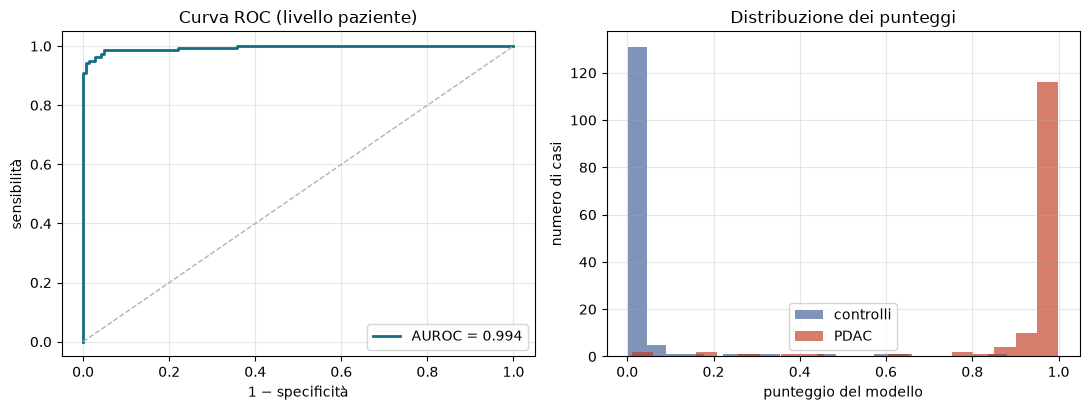

In [10]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

d = df[df["errore"].fillna("").astype(str).str.len() == 0].dropna(subset=["score"])
y = d["etichetta"].astype(int).values
s = d["score"].values

_esclusi = len(df) - len(d)
if _esclusi:
    print(f"ATTENZIONE: {_esclusi} casi esclusi (errore o punteggio mancante).\n")

if len(np.unique(y)) < 2:
    print("Servono entrambi i gruppi (PDAC e controlli) per calcolare l'AUROC.")
    print("(se ti aspettavi entrambi, guarda la colonna 'errore' del CSV)")
else:
    auroc = roc_auc_score(y, s)

    # intervallo di confidenza con bootstrap
    rng = np.random.default_rng(42)
    boot = []
    for _ in range(2000):
        idx = rng.integers(0, len(y), len(y))
        if len(np.unique(y[idx])) == 2:
            boot.append(roc_auc_score(y[idx], s[idx]))
    lo, hi = np.percentile(boot, [2.5, 97.5])

    print("=" * 62)
    print(f"  AUROC = {auroc:.3f}   (IC 95%: {lo:.3f} – {hi:.3f})")
    print("=" * 62)
    print(f"  casi: {int((y==1).sum())} PDAC / {int((y==0).sum())} controlli")
    print(f"  punteggio mediano  PDAC : {np.median(s[y==1]):.3f}")
    print(f"  punteggio mediano  sani : {np.median(s[y==0]):.3f}")

    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
    fpr, tpr, _ = roc_curve(y, s)
    ax[0].plot(fpr, tpr, lw=2, color="#126E82", label=f"AUROC = {auroc:.3f}")
    ax[0].plot([0, 1], [0, 1], "--", color="0.7", lw=1)
    ax[0].set_xlabel("1 − specificità"); ax[0].set_ylabel("sensibilità")
    ax[0].set_title("Curva ROC (livello paziente)"); ax[0].legend(); ax[0].grid(alpha=.3)

    ax[1].hist(s[y == 0], bins=20, alpha=.65, label="controlli", color="#3B5B92")
    ax[1].hist(s[y == 1], bins=20, alpha=.65, label="PDAC", color="#C1381E")
    ax[1].set_xlabel("punteggio del modello"); ax[1].set_ylabel("numero di casi")
    ax[1].set_title("Distribuzione dei punteggi"); ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

### AP a livello di lesione (facoltativo)

Questa cella gira **solo** se hai impostato `PDAC_LABELS` e salvato le mappe di detection.
Usa `picai_eval`, lo stesso strumento della challenge, così i numeri sono confrontabili
con quelli pubblicati.

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_eval


  AP    = 0.918   (localizzazione della lesione)
  AUROC = 0.994   (ricalcolato da picai_eval)
  casi valutati: 286   (saltati: 0)


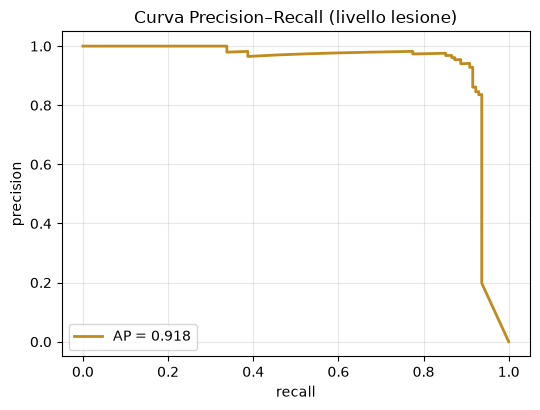

In [11]:
if PDAC_LABELS is None or not SAVE_DETECTION_MAPS:
    print("AP non calcolata: servono PDAC_LABELS e SAVE_DETECTION_MAPS = True.")
else:
    from picai_eval import evaluate

    # ATTENZIONE — la ground truth deve contenere SOLO il tumore.
    # Le segmentazioni PANORAMA sono multi-classe in un unico file
    # (0=sfondo, 1=TUMORE, 2=vene, 3=arterie, 4=parenchima, 5=dotto, 6=coledoco):
    # prendere "tutto ciò che è > 0" farebbe passare l'intero pancreas per tumore
    # e l'AP risulterebbe priva di senso. Il valutatore ufficiale usa infatti
    # `y_true_postprocess_func=lambda lbl: (lbl == 1)`. Con maschere gia' binarie
    # (solo tumore) il risultato e' identico, quindi va bene in entrambi i casi.
    SOLO_TUMORE = lambda lbl: (lbl == 1).astype(int)

    # Passiamo PERCORSI, non array: picai_eval li legge uno alla volta.
    # Tenere in memoria tutte le mappe (fino a ~900 MB l'una) esaurirebbe la RAM.
    ZERI_DIR = OUTPUT_DIR / "gt_controlli"          # GT vuote per i controlli
    ZERI_DIR.mkdir(parents=True, exist_ok=True)

    y_det, y_true, ids, saltati = [], [], [], []
    for _, r in d.iterrows():
        mappa = MAPS_DIR / r["gruppo"] / f"{r['case_id']}.nii.gz"
        if not mappa.exists():
            saltati.append(f"{r['case_id']}: manca la mappa di detection"); continue

        if r["gruppo"] == "PDAC":
            gt_path = Path(PDAC_LABELS) / f"{r['case_id']}.nii.gz"
            if not gt_path.exists():
                saltati.append(f"{r['case_id']}: manca la segmentazione manuale"); continue
            # verifica che ci sia davvero del tumore (classe 1) in quel file
            if int((sitk.GetArrayFromImage(sitk.ReadImage(str(gt_path))) == 1).sum()) == 0:
                saltati.append(f"{r['case_id']}: nessun voxel di tumore (classe 1) nella GT"); continue
        else:
            # i controlli non hanno lesioni: creiamo una GT tutta a zero, una volta sola
            gt_path = ZERI_DIR / f"{r['gruppo']}_{r['case_id']}.nii.gz"
            if not gt_path.exists():
                det_img = sitk.ReadImage(str(mappa))
                vuota = sitk.GetImageFromArray(np.zeros(det_img.GetSize()[::-1], dtype=np.uint8))
                vuota.CopyInformation(det_img)
                sitk.WriteImage(vuota, str(gt_path), useCompression=True)

        # id univoco "gruppo_caso": picai_eval indicizza per id e due omonimi
        # in PDAC/ e health/ si sovrascriverebbero a vicenda, sparendo dal conteggio
        y_det.append(str(mappa)); y_true.append(str(gt_path))
        ids.append(f"{r['gruppo']}_{r['case_id']}")

    for s in saltati[:10]:
        print(f"  (salto {s})")
    if len(saltati) > 10:
        print(f"  (... e altri {len(saltati)-10} casi saltati)")

    n_pos = sum(1 for _, r in d.iterrows() if r["gruppo"] == "PDAC")
    if not y_det:
        print("\nNessun caso valutabile: controlla PDAC_LABELS e le mappe di detection.")
    elif n_pos == 0 or all(Path(t).parent == ZERI_DIR for t in y_true):
        # senza nemmeno un caso positivo picai_eval restituisce AP = -0.0 e AUROC = nan,
        # numeri che sembrano risultati ma non lo sono: meglio fermarsi qui.
        print("\nAP NON calcolabile: non c'è nessun caso con tumore annotato.")
    else:
        metrics = evaluate(y_det=y_det, y_true=y_true, subject_list=ids,
                           min_overlap=0.10,                 # criterio ufficiale: IoU >= 0.10
                           y_true_postprocess_func=SOLO_TUMORE)
        print("\n" + "=" * 62)
        print(f"  AP    = {metrics.AP:.3f}   (localizzazione della lesione)")
        print(f"  AUROC = {metrics.auroc:.3f}   (ricalcolato da picai_eval)")
        print("=" * 62)
        print(f"  casi valutati: {len(ids)}   (saltati: {len(saltati)})")

        plt.figure(figsize=(5.5, 4.2))
        plt.plot(metrics.recall, metrics.precision, lw=2, color="#C18A1E", label=f"AP = {metrics.AP:.3f}")
        plt.xlabel("recall"); plt.ylabel("precision")
        plt.title("Curva Precision–Recall (livello lesione)")
        plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

In [12]:
import datetime, pandas as pd

riga = {
    "modello": "baseline PANORAMA",
    "data": datetime.datetime.now().isoformat(timespec="seconds"),
    "dataset": "PANORAMA public dev set (= training set)",
    "n_pdac": int((y == 1).sum()),
    "n_controlli": int((y == 0).sum()),
    "AUROC": round(float(auroc), 4),
    "AUROC_IC95_lo": round(float(lo), 4),
    "AUROC_IC95_hi": round(float(hi), 4),
    "AUROC_picai": round(float(metrics.auroc), 4),
    "AP": round(float(metrics.AP), 4),
    "min_overlap": 0.10,
    "folds": "-".join(map(str, FOLDS)),
    "TTA": bool(USE_TTA),
    "casi_valutati": len(ids),
    "casi_saltati": len(saltati),
    "note": "IC bootstrap degenere (separazione perfetta)",
}

p = Path.home() / "Desktop/PhD_pancreas/metriche.csv"
p = OUTPUT_DIR / "metriche.csv"
nuovo = pd.DataFrame([riga])
if p.exists():
    nuovo = pd.concat([pd.read_csv(p), nuovo], ignore_index=True)
nuovo.to_csv(p, index=False)

print("salvato:", p)
print(nuovo.to_string())

salvato: /home/radiology/Desktop/PhD_pancreas/panorama-inference/baseline_pdac/risultati/metriche.csv
             modello                 data                                   dataset  n_pdac  n_controlli   AUROC  AUROC_IC95_lo  AUROC_IC95_hi  AUROC_picai     AP  min_overlap      folds   TTA  casi_valutati  casi_saltati                                          note
0  baseline PANORAMA  2026-08-07T20:31:01  PANORAMA public dev set (= training set)     141          145  0.9942         0.9868         0.9991       0.9942  0.918          0.1  0-1-2-3-4  True            286             0  IC bootstrap degenere (separazione perfetta)


In [13]:
print([a for a in dir(metrics) if not a.startswith('_')])
import pandas as pd

righe = []
for sid, lesioni in metrics.lesion_results.items():
    for i, t in enumerate(lesioni):
        righe.append({
            "caso": sid,
            "candidato": i,
            "e_vera_lesione": int(t[0]),      # 1 = ha centrato la GT, 0 = falso positivo
            "confidenza": float(t[1]),
            "sovrapposizione": float(t[2]) if len(t) > 2 else None,
        })

det = pd.DataFrame(righe).sort_values(["caso", "confidenza"], ascending=[True, False])
det.to_csv(OUTPUT_DIR / "dettaglio_lesioni.csv", index=False)
print(det.to_string())

print("\nRiepilogo per caso:")
print(det.groupby("caso").agg(
    candidati=("candidato", "count"),
    veri_positivi=("e_vera_lesione", "sum"),
    conf_max=("confidenza", "max"),
).to_string())

['AP', 'as_dict', 'auroc', 'bootstrap_score_ci', 'calc_AP', 'calc_auroc', 'calc_case_FPR', 'calc_case_TPR', 'calculate_ROC', 'calculate_counts', 'calculate_precision_recall', 'case_FPR', 'case_TPR', 'case_pred', 'case_target', 'case_weight', 'full_dict', 'get_lesion_results_flat', 'get_lesion_weight_flat', 'lesion_FP', 'lesion_FPR', 'lesion_TP', 'lesion_TPR', 'lesion_TPR_at_FPR', 'lesion_results', 'lesion_results_flat', 'lesion_weight', 'lesion_weight_flat', 'load', 'minimal_dict', 'num_cases', 'num_lesions', 'precision', 'recall', 'save', 'save_full', 'save_minimal', 'score', 'sort', 'subject_list', 'thresholds', 'version']
           caso  candidato  e_vera_lesione  confidenza  sovrapposizione
0     PDAC_0003          0               1    0.992578         0.822485
1     PDAC_0005          0               1    0.992778         0.528079
2     PDAC_0008          0               1    0.989525         0.462963
3     PDAC_0013          0               1    0.997605         0.525471
4     P

---
## 7-bis · Verifica e controllo di qualità delle segmentazioni

Due controlli, in ordine di importanza.

**Integrità** — la segmentazione deve avere la stessa forma e la stessa geometria della TC di
partenza, e contenere solo valori 0–6. Se il reincollaggio avesse sbagliato, te ne accorgi qui e
non a analisi conclusa.

**Frammentazione** — l'argmax non impone nessun vincolo spaziale: una classe può uscire in più
pezzi staccati. Il dotto pancreatico è il caso tipico, ed è anche quello da cui si misura il
calibro. Un dotto in cinque tronconi rende quella misura inaffidabile.


In [14]:
# ============================================================================
#  Verifica di integrità e statistiche per classe
# ============================================================================
from scipy.ndimage import label as _componenti_connesse

if not SEG_DIR.exists():
    print("Nessuna segmentazione trovata: esegui il punto 6 con l'estensione del 4-bis attiva.")
else:
    # percorso della TC per ogni caso, ricostruito dalla lista `lavoro` del punto 6
    _path_di = {f"{g}/{id_del_caso(p)}": p for _, p, g, _e in lavoro}

    righe, problemi = [], []
    for _, rr in d.iterrows():
        chiave = f"{rr['gruppo']}/{rr['case_id']}"
        seg_p = SEG_DIR / rr["gruppo"] / f"{rr['case_id']}.nii.gz"
        if not seg_p.exists():
            problemi.append(f"{chiave}: segmentazione assente"); continue

        seg_img = sitk.ReadImage(str(seg_p))
        seg = sitk.GetArrayFromImage(seg_img)

        # --- integrità rispetto alla TC originale ---
        ct_p = _path_di.get(chiave)
        if ct_p is not None:
            ct_img = sitk.ReadImage(str(ct_p))
            if seg_img.GetSize() != ct_img.GetSize():
                problemi.append(f"{chiave}: dimensioni diverse dalla TC "
                                f"({seg_img.GetSize()} vs {ct_img.GetSize()})")
            if not np.allclose(seg_img.GetSpacing(), ct_img.GetSpacing(), atol=1e-4):
                problemi.append(f"{chiave}: spacing diverso dalla TC")
            if not np.allclose(seg_img.GetOrigin(), ct_img.GetOrigin(), atol=1e-3):
                problemi.append(f"{chiave}: origine diversa dalla TC")

        val = set(np.unique(seg).tolist())
        if val - set(ETICHETTE):
            problemi.append(f"{chiave}: valori fuori da 0-6 -> {sorted(val - set(ETICHETTE))}")

        riga = {"chiave": chiave, "gruppo": rr["gruppo"], "score": rr["score"]}
        for k, nome in ETICHETTE.items():
            if k == 0:
                continue
            m = (seg == k)
            n_vox = int(m.sum())
            riga[f"vox_{k}"] = n_vox
            riga[f"comp_{k}"] = int(_componenti_connesse(m)[1]) if n_vox else 0
        righe.append(riga)

    qc = pd.DataFrame(righe)
    if problemi:
        print("PROBLEMI DI INTEGRITÀ:")
        for p_ in problemi[:20]:
            print("   [X]", p_)
        print()
    else:
        print("Integrità OK: forma, spacing, origine e intervallo dei valori corretti "
              f"su tutti i {len(qc)} casi.\n")

    if len(qc):
        print("VOXEL PER CLASSE (mediana sui casi)")
        for k, nome in ETICHETTE.items():
            if k == 0:
                continue
            med = int(qc[f"vox_{k}"].median())
            vuoti = int((qc[f"vox_{k}"] == 0).sum())
            print(f"   {k}  {nome:<20} mediana {med:>9,} voxel   ·  assente in {vuoti}/{len(qc)} casi")

        print("\nFRAMMENTAZIONE (numero di componenti connesse, mediana)")
        for k, nome in ETICHETTE.items():
            if k == 0:
                continue
            med_c = qc[f"comp_{k}"].median()
            peggio = int(qc[f"comp_{k}"].max())
            flag = "  <-- da controllare" if med_c > 3 else ""
            print(f"   {k}  {nome:<20} mediana {med_c:>5.1f}   massimo {peggio:>4}{flag}")

        # --- il controllo che conta di piu' ---
        print("\nTUMORE (classe 1) NEI CONTROLLI")
        ctrl = qc[qc["gruppo"] != "PDAC"]
        if len(ctrl):
            n_fp = int((ctrl["vox_1"] > 0).sum())
            print(f"   {n_fp} controlli su {len(ctrl)} hanno voxel di classe 1 (falsi positivi).")
            if n_fp:
                print("   Da far rivedere a un radiologo:")
                for _, x in ctrl[ctrl["vox_1"] > 0].iterrows():
                    print(f"      {x['chiave']}  ({int(x['vox_1'])} voxel, score {x['score']:.3f})")
        else:
            print("   nessun controllo in questa coorte.")

        print("\nTUMORE (classe 1) NEI CASI PDAC")
        pos = qc[qc["gruppo"] == "PDAC"]
        if len(pos):
            n_vuoti = int((pos["vox_1"] == 0).sum())
            print(f"   {n_vuoti} casi su {len(pos)} senza alcun voxel di tumore.")
            print("   -> misura MANCANTE per la fase prognostica, non caso da escludere.")

        QC_PATH = OUTPUT_DIR / "qc_segmentazioni.csv"
        qc.to_csv(QC_PATH, index=False)
        print(f"\nTabella completa salvata in: {QC_PATH}")
    qc.head(10)


Integrità OK: forma, spacing, origine e intervallo dei valori corretti su tutti i 286 casi.

VOXEL PER CLASSE (mediana sui casi)
   1  lesione PDAC         mediana         0 voxel   ·  assente in 149/286 casi
   2  vene                 mediana     9,279 voxel   ·  assente in 0/286 casi
   3  arterie              mediana    17,357 voxel   ·  assente in 0/286 casi
   4  parenchima           mediana    23,096 voxel   ·  assente in 0/286 casi
   5  dotto pancreatico    mediana        14 voxel   ·  assente in 103/286 casi
   6  coledoco             mediana       126 voxel   ·  assente in 44/286 casi

FRAMMENTAZIONE (numero di componenti connesse, mediana)
   1  lesione PDAC         mediana   0.0   massimo    5
   2  vene                 mediana   1.0   massimo   10
   3  arterie              mediana   4.0   massimo   13  <-- da controllare
   4  parenchima           mediana   1.0   massimo   13
   5  dotto pancreatico    mediana   1.0   massimo    9
   6  coledoco             mediana   1.0 

### Campione per la revisione radiologica

Le classi 2–6 non hanno una verità di riferimento umana, né qui né nel dataset pubblico.
L'unico controllo che ne dice davvero l'accuratezza è **guardarle**. La cella qui sotto estrae un
campione casuale riproducibile (`SEED`) e stampa i percorsi da aprire in ITK-SNAP o 3D Slicer,
affiancando TC e segmentazione.


In [15]:
# ============================================================================
#  Campione casuale per la revisione visiva
# ============================================================================
N_CAMPIONE = 10
SEED_QC = 42

if "qc" not in dir() or not len(qc):
    print("Esegui prima la cella di controllo qualità qui sopra.")
else:
    n = min(N_CAMPIONE, len(qc))
    camp = qc.sample(n=n, random_state=SEED_QC).sort_values("chiave")
    print(f"{n} casi estratti a caso (seed {SEED_QC}) — aprire TC e segmentazione sovrapposte:\n")
    for _, x in camp.iterrows():
        g, cid = x["chiave"].split("/", 1)
        ct = _path_di.get(x["chiave"])
        sg = SEG_DIR / g / f"{cid}.nii.gz"
        print(f"  {x['chiave']}")
        print(f"     TC   : {ct}")
        print(f"     SEG  : {sg}")
    print("\nPer ciascuna struttura annotare: accettabile / errore minore / inutilizzabile.")
    print("Le classi 5 (dotto) e 6 (coledoco) sono quelle piu' a rischio.")


10 casi estratti a caso (seed 42) — aprire TC e segmentazione sovrapposte:

  PDAC/0043
     TC   : /home/radiology/Desktop/PhD_pancreas/panorama-inference/dati_tc/PDAC/images/0043.nii.gz
     SEG  : /home/radiology/Desktop/PhD_pancreas/panorama-inference/baseline_pdac/risultati/segmentazioni/PDAC/0043.nii.gz
  PDAC/0139
     TC   : /home/radiology/Desktop/PhD_pancreas/panorama-inference/dati_tc/PDAC/images/0139.nii.gz
     SEG  : /home/radiology/Desktop/PhD_pancreas/panorama-inference/baseline_pdac/risultati/segmentazioni/PDAC/0139.nii.gz
  PDAC/0272
     TC   : /home/radiology/Desktop/PhD_pancreas/panorama-inference/dati_tc/PDAC/images/0272.nii.gz
     SEG  : /home/radiology/Desktop/PhD_pancreas/panorama-inference/baseline_pdac/risultati/segmentazioni/PDAC/0272.nii.gz
  health/003
     TC   : /home/radiology/Desktop/PhD_pancreas/panorama-inference/dati_tc/health/images/003.nii.gz
     SEG  : /home/radiology/Desktop/PhD_pancreas/panorama-inference/baseline_pdac/risultati/segmentazioni

### Verifica degli embedding

Controlla che i due CSV siano coerenti: numero di righe atteso, 320 colonne di feature,
nessun valore mancante, e quanto i fold divergono fra loro sullo stesso paziente.

Il paziente è identificato da **`gruppo/case_id`**, non dal solo `case_id`: i numeri di caso
si ripetono fra le cartelle PDAC e health, e raggrupparli per il solo numero fonderebbe
pazienti diversi in un unico gruppo. La cella segnala quanti identificativi collidono.

In [7]:
import pandas as pd, numpy as np
from pathlib import Path

EMB_CSV_SEMPLICE = OUTPUT_DIR / "embedding_media_semplice.csv"
EMB_CSV_PESATA   = OUTPUT_DIR / "embedding_media_pesata.csv"
WIDE_CSV_SEMPLICE = OUTPUT_DIR / "embedding_media_semplice_per_paziente.csv"
WIDE_CSV_PESATA   = OUTPUT_DIR / "embedding_media_pesata_per_paziente.csv"

# ============================================================================
#  Verifica dei CSV di embedding
#  CORREZIONE: la chiave del paziente e' gruppo + case_id, non il solo case_id.
# ============================================================================
def _chiave_paziente(e):
    """I numeri di caso si ripetono fra le cartelle PDAC e health:
    raggruppare per il solo case_id fonde pazienti diversi."""
    if "gruppo" in e.columns:
        return (e["gruppo"].astype(str) + "/" + e["case_id"].astype(str)).rename("chiave")
    print("    ATTENZIONE: colonna 'gruppo' assente: uso il solo case_id, "
          "pazienti diversi potrebbero essere fusi.")
    return e["case_id"].astype(str).rename("chiave")


if not EMB_CSV_SEMPLICE.exists():
    print("Nessun embedding trovato: esegui il punto 6 con l'estensione del 4-bis attiva.")
else:
    for nome, path in (("MEDIA SEMPLICE", EMB_CSV_SEMPLICE), ("MEDIA PESATA", EMB_CSV_PESATA)):
        e = pd.read_csv(path)
        chiave = _chiave_paziente(e)          # Serie separata: non tocca il frame
        col = [c for c in e.columns if c.startswith("emb_")]
        pazienti = chiave.nunique()

        print(f"--- {nome}")
        print(f"    righe {len(e)}  ·  pazienti {pazienti}  ·  colonne feature {len(col)}")

        # diagnosi delle collisioni di identificativo
        n_id = e["case_id"].nunique()
        if "gruppo" in e.columns and n_id != pazienti:
            d = (pd.DataFrame({"case_id": e["case_id"].astype(str),
                               "gruppo":  e["gruppo"].astype(str)})
                   .drop_duplicates().groupby("case_id")["gruppo"].nunique())
            d = d[d > 1]
            print(f"    {len(d)} case_id compaiono in piu' di un gruppo "
                  f"({n_id} id distinti per {pazienti} pazienti reali).")
            print(f"    Risolti con la chiave gruppo/case_id. Esempi: "
                  f"{', '.join(map(str, d.index[:5]))}")

        attese = pazienti * len(FOLDS)
        if len(e) != attese:
            print(f"    ATTENZIONE: attese {attese} righe ({pazienti} pazienti x {len(FOLDS)} fold).")
        if len(col) != 320:
            print(f"    ATTENZIONE: {len(col)} colonne di feature invece di 320.")
        n_nan = int(e[col].isna().sum().sum())
        if n_nan:
            print(f"    ATTENZIONE: {n_nan} valori mancanti.")
        if "ripiego_su_semplice" in e.columns:
            rip = int(e["ripiego_su_semplice"].sum())
            if rip:
                print(f"    {rip} righe con ripiego sulla media semplice (nessun voxel sospetto).")

        per_paz = e.groupby(chiave).size()
        if per_paz.nunique() != 1:
            print(f"    ATTENZIONE: righe per paziente non costanti "
                  f"(min {per_paz.min()}, max {per_paz.max()}, attese {len(FOLDS)}).")

        sd_fold = e.groupby(chiave)[col].std(ddof=1).mean(axis=1).dropna()
        sd_comp = e[col].mean(axis=0).std()
        print(f"    dispersione media fra i {len(FOLDS)} fold : {sd_fold.mean():.5f}")
        print(f"    dispersione fra le 320 componenti        : {sd_comp:.5f}")
        print("    (indicatore grezzo: quello che conta e' nella cella successiva)")
        print()

    print("Nota: 320 feature contro poche centinaia di pazienti. Qualunque analisi a valle")
    print("richiede cross-validation annidata, altrimenti il risultato e' ottimisticamente distorto.")


--- MEDIA SEMPLICE
    righe 1430  ·  pazienti 286  ·  colonne feature 320
    49 case_id compaiono in piu' di un gruppo (237 id distinti per 286 pazienti reali).
    Risolti con la chiave gruppo/case_id. Esempi: 105, 107, 13, 158, 16
    dispersione media fra i 5 fold : 0.00793
    dispersione fra le 320 componenti        : 0.00377
    (indicatore grezzo: quello che conta e' nella cella successiva)

--- MEDIA PESATA
    righe 1430  ·  pazienti 286  ·  colonne feature 320
    49 case_id compaiono in piu' di un gruppo (237 id distinti per 286 pazienti reali).
    Risolti con la chiave gruppo/case_id. Esempi: 105, 107, 13, 158, 16
    dispersione media fra i 5 fold : 0.00793
    dispersione fra le 320 componenti        : 0.00376
    (indicatore grezzo: quello che conta e' nella cella successiva)

Nota: 320 feature contro poche centinaia di pazienti. Qualunque analisi a valle
richiede cross-validation annidata, altrimenti il risultato e' ottimisticamente distorto.


### Rapporto rumore/segnale dell'embedding

Un embedding serve a qualcosa **solo se distingue un paziente dall'altro**. Il confronto che conta è
quindi fra due quantità, calcolate componente per componente:

| | Come si calcola | Cosa rappresenta |
|---|---|---|
| **Rumore** | deviazione standard fra i 5 fold, **dentro** lo stesso paziente, mediata sui pazienti | quanto cambia la misura solo cambiando rete |
| **Segnale** | deviazione standard **fra** pazienti, sui vettori mediati sui fold | quanto i pazienti differiscono davvero |

Il loro **rapporto** dice se la misura è utilizzabile:

- **< 1** → il modello è stabile abbastanza: le differenze fra pazienti superano il rumore
- **≈ 1 o > 1** → stai misurando il modello, non il paziente

> ⚠️ Questa cella **sostituisce** l'indicatore grezzo stampato nella cella precedente, dove il
> denominatore era la dispersione fra le 320 componenti — una quantità scollegata dalla domanda.
> Fai riferimento ai numeri prodotti qui.
>
> ⚠️ Servono **molti pazienti** perché il denominatore sia una stima e non un aneddoto.
> Con pochi casi la cella calcola comunque il valore, ma lo segnala come non interpretabile.
>
> > ⚠️ I fold sono reti **addestrate separatamente**: i loro spazi a 320 dimensioni non sono
> allineati fra loro, quindi mediarli può distruggere il segnale anche quando il singolo fold
> ce l'ha. Se il rapporto resta alto, guarda la riga finale — `variabilità fra pazienti dentro
> un singolo fold` — prima di concludere che l'embedding non serve: la strada alternativa è
> usare **un fold solo** (320 componenti) invece della media sui cinque.



In [8]:
# ============================================================================
#  Rapporto rumore/segnale, componente per componente
#  CORREZIONE: chiave paziente = gruppo + case_id.
#  In piu': controprova su un singolo fold.
# ============================================================================
RAPP_CSV_SEMPLICE = OUTPUT_DIR / "rapporto_rumore_segnale_media_semplice.csv"
RAPP_CSV_PESATA   = OUTPUT_DIR / "rapporto_rumore_segnale_media_pesata.csv"
N_PAZIENTI_MINIMO = 20

def _chiave_paziente(e):
    if "gruppo" in e.columns:
        return (e["gruppo"].astype(str) + "/" + e["case_id"].astype(str)).rename("chiave")
    print("    ATTENZIONE: colonna 'gruppo' assente: uso il solo case_id.")
    return e["case_id"].astype(str).rename("chiave")


def _rapporto_rumore_segnale(path_csv, path_out, nome):
    if not Path(path_csv).exists():
        print(f"--- {nome}: file assente ({Path(path_csv).name}), salto.")
        return None
    e = pd.read_csv(path_csv)
    chiave = _chiave_paziente(e)
    col = [c for c in e.columns if c.startswith("emb_")]
    n_paz  = chiave.nunique()
    n_fold = e["fold"].nunique()

    print(f"--- {nome}")
    print(f"    pazienti {n_paz}  ·  fold {n_fold}  ·  componenti {len(col)}")
    if n_paz < 2:
        print("    IMPOSSIBILE: servono almeno 2 pazienti."); return None
    if n_fold < 2:
        print("    IMPOSSIBILE: servono almeno 2 fold per stimare il rumore."); return None

    # RUMORE: sd fra i fold dentro lo stesso paziente, poi media sui pazienti
    sd_fold = e.groupby(chiave)[col].std(ddof=1).mean(axis=0)
    # SEGNALE: sd fra pazienti, sui vettori mediati sui fold
    consenso = e.groupby(chiave)[col].mean()
    sd_paz   = consenso.std(axis=0, ddof=1)

    with np.errstate(divide="ignore", invalid="ignore"):
        rapp = sd_fold / sd_paz
    rapp = rapp.replace([np.inf, -np.inf], np.nan)

    fuori = pd.DataFrame({"componente": col,
                          "sd_fra_fold": sd_fold.values,
                          "sd_fra_pazienti": sd_paz.values,
                          "rapporto_rumore_segnale": rapp.values})
    fuori.to_csv(path_out, index=False)

    val = fuori["rapporto_rumore_segnale"].dropna()
    if len(val) == 0:
        print("    Nessun rapporto calcolabile."); return fuori
    print(f"    rapporto mediano            : {val.median():.3f}")
    print(f"    intervallo (p10 - p90)      : {val.quantile(.10):.3f} - {val.quantile(.90):.3f}")
    print(f"    componenti con rapporto < 1 : {int((val<1).sum())}/{len(val)}"
          f"  ({100*float((val<1).mean()):.1f} %)")
    if n_paz < N_PAZIENTI_MINIMO:
        print(f"    ATTENZIONE: solo {n_paz} pazienti: numeri non interpretabili.")
    elif val.median() >= 1:
        print("    Il rumore del modello supera la variabilita' fra pazienti:")
        print("    l'embedding, COSI' AGGREGATO SUI FOLD, non distingue i pazienti.")
    else:
        print("    Il segnale fra pazienti supera il rumore del modello.")

    # CONTROPROVA: i fold sono reti addestrate separatamente, i loro spazi a 320
    # dimensioni non sono allineati e mediarli puo' non avere senso. Qui si guarda
    # quanto separa i pazienti UN SINGOLO fold.
    print("    variabilita' fra pazienti dentro un singolo fold (mediana sulle componenti):")
    for f, sub in e.groupby("fold"):
        c = sub.groupby(_chiave_paziente(sub))[col].mean()
        if len(c) > 1:
            print(f"      fold {f}: {len(c)} pazienti, sd {float(c.std(axis=0, ddof=1).median()):.5f}")
    print(f"    salvato in: {Path(path_out).name}")
    return fuori


if not EMB_CSV_SEMPLICE.exists():
    print("Nessun embedding trovato: esegui prima il punto 6 con l'estensione del 4-bis attiva.")
else:
    _r_sem = _rapporto_rumore_segnale(EMB_CSV_SEMPLICE, RAPP_CSV_SEMPLICE, "MEDIA SEMPLICE")
    print()
    _r_pes = _rapporto_rumore_segnale(EMB_CSV_PESATA,   RAPP_CSV_PESATA,   "MEDIA PESATA")
    print("\nUn rapporto vicino o superiore a 1 non e' un fallimento tecnico: e' un risultato,")
    print("e va riportato. Dice quanta parte della misura dipende dal modello e non dal paziente.")


--- MEDIA SEMPLICE
    pazienti 286  ·  fold 5  ·  componenti 320
    rapporto mediano            : 23.568
    intervallo (p10 - p90)      : 11.527 - 42.267
    componenti con rapporto < 1 : 0/320  (0.0 %)
    Il rumore del modello supera la variabilita' fra pazienti:
    l'embedding, COSI' AGGREGATO SUI FOLD, non distingue i pazienti.
    variabilita' fra pazienti dentro un singolo fold (mediana sulle componenti):
      fold 0: 286 pazienti, sd 0.00042
      fold 1: 286 pazienti, sd 0.00043
      fold 2: 286 pazienti, sd 0.00049
      fold 3: 286 pazienti, sd 0.00041
      fold 4: 286 pazienti, sd 0.00042
    salvato in: rapporto_rumore_segnale_media_semplice.csv

--- MEDIA PESATA
    pazienti 286  ·  fold 5  ·  componenti 320
    rapporto mediano            : 20.435
    intervallo (p10 - p90)      : 9.982 - 34.271
    componenti con rapporto < 1 : 0/320  (0.0 %)
    Il rumore del modello supera la variabilita' fra pazienti:
    l'embedding, COSI' AGGREGATO SUI FOLD, non distingue i p

### Una riga per paziente

Le celle precedenti lavorano sul formato **lungo**: una riga per paziente e per fold. È
necessario così, perché la dispersione fra fold si calcola solo avendo i fold su righe separate.

Questa cella ne produce una copia in formato **largo**: una riga per paziente, con le componenti
affiancate come `emb_000_fold_0` … `emb_319_fold_4`. I file di partenza non vengono toccati.

**Prima di usare questo file per predire qualcosa.** Sono 1600 feature per paziente contro poche
centinaia di pazienti. Peggio: `emb_000_fold_0` e `emb_000_fold_1` non misurano la stessa cosa,
perché vengono da due reti diverse — affiancarle moltiplica le colonne per cinque senza aggiungere
informazione allineata. Il formato largo serve a ispezionare i dati e a confrontare i fold fra
loro; per una analisi prognostica conviene partire da **un solo fold**.


In [9]:
# ============================================================================
#  Da formato lungo a formato largo: UNA RIGA PER PAZIENTE
#  Cella AGGIUNTIVA: non modifica nulla di quanto precede.
#  I due CSV di partenza (una riga per paziente x fold) restano intatti:
#  servono alle celle di verifica, che senza i fold su righe separate non
#  possono calcolare la dispersione fra fold.
# ============================================================================

META_FISSI    = ["gruppo", "case_id", "etichetta"]              # una colonna ciascuno
META_PER_FOLD = ["n_passate", "peso_max", "ripiego_su_semplice"]  # una colonna per fold; [] per ometterli


def _chiave_paziente(e):
    """I numeri di caso si ripetono fra le cartelle PDAC e health:
    la chiave del paziente e' gruppo + case_id."""
    if "gruppo" in e.columns:
        return (e["gruppo"].astype(str) + "/" + e["case_id"].astype(str)).rename("chiave")
    print("    ATTENZIONE: colonna 'gruppo' assente: uso il solo case_id.")
    return e["case_id"].astype(str).rename("chiave")


def _a_formato_largo(path_in, path_out, nome):
    if not Path(path_in).exists():
        print(f"--- {nome}: file assente ({Path(path_in).name}), salto.")
        return None

    e = pd.read_csv(path_in)
    chiave = _chiave_paziente(e)
    col    = [c for c in e.columns if c.startswith("emb_")]
    folds  = sorted(e["fold"].unique())
    n_paz  = chiave.nunique()
    print(f"--- {nome}")
    print(f"    ingresso: {len(e)} righe · {n_paz} pazienti · {len(col)} componenti · fold {folds}")

    # indice (paziente, fold) senza toccare il frame di partenza
    idx = pd.MultiIndex.from_arrays([chiave.values, e["fold"].values], names=["chiave", "fold"])

    dupl = int(idx.duplicated().sum())
    if dupl:
        print(f"    ATTENZIONE: {dupl} righe con la stessa coppia paziente/fold. Tengo la prima.")
    tieni = ~idx.duplicated()
    idx   = idx[tieni]

    n_fold_per_paz = pd.Series(idx.get_level_values(1), index=idx.get_level_values(0)).groupby(level=0).nunique()
    incompleti = n_fold_per_paz[n_fold_per_paz < len(folds)]
    if len(incompleti):
        print(f"    ATTENZIONE: {len(incompleti)} pazienti senza tutti i {len(folds)} fold: "
              f"le colonne mancanti restano vuote. Esempi: {list(incompleti.index[:5])}")

    # blocco delle feature: emb_XXX_fold_Y, ordinate per fold e poi per componente
    largo = pd.DataFrame(e.loc[tieni, col].to_numpy(), index=idx, columns=col).unstack("fold")
    largo.columns = [f"{c}_fold_{f}" for c, f in largo.columns]
    largo = largo.reindex(columns=[f"{c}_fold_{f}" for f in folds for c in col])

    pezzi = [largo]

    # metadati costanti dentro il paziente
    fissi = [c for c in META_FISSI if c in e.columns]
    if fissi:
        t = pd.DataFrame(e.loc[tieni, fissi].to_numpy(), index=idx.get_level_values(0), columns=fissi)
        pezzi.insert(0, t[~t.index.duplicated()])

    # metadati che cambiano da fold a fold
    for m in META_PER_FOLD:
        if m not in e.columns:
            continue
        p = pd.DataFrame(e.loc[tieni, [m]].to_numpy(), index=idx, columns=[m]).unstack("fold")
        p.columns = [f"{m}_fold_{f}" for _, f in p.columns]
        pezzi.append(p.reindex(columns=[f"{m}_fold_{f}" for f in folds]))

    largo = pd.concat(pezzi, axis=1).sort_index()
    largo.index.name = "chiave"
    largo = largo.reset_index()

    attese = 1 + len(fissi) + len(col) * len(folds) + \
             len(folds) * sum(1 for m in META_PER_FOLD if m in e.columns)
    print(f"    uscita  : {len(largo)} righe · {len(largo.columns)} colonne  (attese {attese})")
    if len(largo) != n_paz:
        print(f"    ATTENZIONE: {len(largo)} righe invece di {n_paz} pazienti.")
    if len(largo.columns) != attese:
        print("    ATTENZIONE: numero di colonne inatteso.")
    vuote = int(largo[[c for c in largo.columns if c.startswith('emb_')]].isna().sum().sum())
    if vuote:
        print(f"    ATTENZIONE: {vuote} celle di feature vuote.")

    largo.to_csv(path_out, index=False)
    print(f"    salvato : {Path(path_out).name}")
    return largo


if not EMB_CSV_SEMPLICE.exists():
    print("Nessun embedding trovato: esegui prima il punto 6 con l'estensione del 4-bis attiva.")
else:
    _w_sem = _a_formato_largo(EMB_CSV_SEMPLICE, WIDE_CSV_SEMPLICE, "MEDIA SEMPLICE")
    print()
    _w_pes = _a_formato_largo(EMB_CSV_PESATA,   WIDE_CSV_PESATA,   "MEDIA PESATA")
    if _w_pes is not None:
        n_feat = sum(1 for c in _w_pes.columns if c.startswith("emb_"))
        print(f"\n{n_feat} colonne di feature per paziente, su {len(_w_pes)} pazienti.")
        print("Vedi la nota qui sotto prima di usarle per predire qualcosa.")


--- MEDIA SEMPLICE
    ingresso: 1430 righe · 286 pazienti · 320 componenti · fold [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
    uscita  : 286 righe · 1619 colonne  (attese 1619)
    salvato : embedding_media_semplice_per_paziente.csv

--- MEDIA PESATA
    ingresso: 1430 righe · 286 pazienti · 320 componenti · fold [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
    uscita  : 286 righe · 1619 colonne  (attese 1619)
    salvato : embedding_media_pesata_per_paziente.csv

1600 colonne di feature per paziente, su 286 pazienti.
Vedi la nota qui sotto prima di usarle per predire qualcosa.


---
## 8 · Benchmark: il codice riproduce i risultati ufficiali? *(facoltativo)*

Prima di fidarti dei punteggi sui tuoi dati, è ragionevole chiedersi:
**questa pipeline si comporta come quella originale?**

Si può verificare usando i **2238 casi pubblici** di PANORAMA (quelli che scarichi da
Zenodo, non il test set segreto). C'è però una trappola:

> Il baseline è stato **addestrato** su quei casi. Se ci fai girare il modello sopra
> e basta, i punteggi sono **gonfiati** — il modello li ha già visti.

La soluzione è la valutazione **out-of-fold**, ed è possibile perché gli autori hanno
pubblicato la suddivisione ufficiale in 5 fold:

- ogni caso è stato usato per **addestrare** 4 fold e per **validare** 1 fold;
- se per ogni caso usi **solo il modello della fold che NON l'ha visto**, ottieni una
  predizione onesta;
- l'AUROC che ne esce è confrontabile con quello pubblicato.

⚠️ **Costo:** su GPU sono ore, su CPU **giorni**. Falla girare sulla macchina con GPU.

In [ ]:
# ============================================================================
#  Benchmark out-of-fold sui casi pubblici PANORAMA
#  Attiva questa cella solo se hai i casi PANORAMA e (preferibilmente) una GPU.
# ============================================================================
ESEGUI_BENCHMARK = True          # <-- metti True per lanciarlo

# i casi pubblici PANORAMA stanno nella cartella del progetto, un livello sopra
PANORAMA_IMAGES   = BASE_DIR.parent / "imagesTr"                              # {study_id}_0000.nii.gz
PANORAMA_CLINICAL = BASE_DIR.parent / "cache" / "clinical_information.xlsx"   # etichette vere

BENCH_CSV = OUTPUT_DIR / "benchmark_out_of_fold.csv"

if not ESEGUI_BENCHMARK:
    print("Benchmark disattivato (ESEGUI_BENCHMARK = False).")
else:
    import json

    # 1) suddivisione ufficiale in fold, dal repo del baseline.
    #    Se e' gia' stata salvata in locale la usa, altrimenti la scarica.
    #    (uso `requests` e non `urllib`: su alcuni Mac urllib fallisce con
    #     "CERTIFICATE_VERIFY_FAILED" perche' non trova i certificati di sistema)
    FOLDS_LOCAL = MODELS_DIR / "Dataset104_folds.json"
    URL_FOLDS = ("https://raw.githubusercontent.com/DIAGNijmegen/PANORAMA_baseline/main/"
                 "src/Dataset104_PANORAMA_baseline_PDAC_Detection_folds.json")
    if FOLDS_LOCAL.exists():
        folds_json = json.loads(FOLDS_LOCAL.read_text())
        print(f"Suddivisione in fold letta da: {FOLDS_LOCAL}")
    else:
        try:
            import requests
            folds_json = requests.get(URL_FOLDS, timeout=60).json()
            FOLDS_LOCAL.write_text(json.dumps(folds_json))   # salva per la prossima volta
        except Exception as e:
            raise SystemExit(
                f"Non riesco a scaricare la suddivisione in fold ({type(e).__name__}).\n"
                f"Scaricala a mano e rilancia:\n"
                f"  curl -L -o '{FOLDS_LOCAL}' '{URL_FOLDS}'")

    # Il file ha questa forma:
    #   {"Fold 0 validation": ["101990_00001", ...], "Fold 1 validation": [...], ...}
    # cioe' per ogni fold l'elenco dei casi usati per VALIDARE (= non visti in addestramento).
    import re
    caso2fold = {}
    for k, casi in folds_json.items():
        fold_idx = int(re.search(r"\d+", k).group())
        for c in casi:
            caso2fold[c] = fold_idx
    print(f"Suddivisione ufficiale caricata: {len(caso2fold)} casi mappati su {len(folds_json)} fold")

    # 2) etichette vere dal file clinico
    clin = pd.read_excel(PANORAMA_CLINICAL)
    etichetta_vera = {r.PANORAMA_study_id: (1 if r.label == "PDAC" else 0) for r in clin.itertuples()}

    # 3) casi disponibili in locale
    disponibili = []
    for p in sorted(Path(PANORAMA_IMAGES).glob("*_0000.nii.gz")):
        sid = p.name.replace("_0000.nii.gz", "")
        if sid in caso2fold and sid in etichetta_vera:
            disponibili.append((sid, p, caso2fold[sid], etichetta_vera[sid]))
    print(f"Casi utilizzabili: {len(disponibili)}")

    # 4) raggruppa per fold: si carica un modello per fold, non uno per caso
    da_fare = {}
    for sid, p, f, y in disponibili:
        da_fare.setdefault(f, []).append((sid, p, y))

    righe = []
    for f in sorted(da_fare):
        print(f"\n--- fold {f}: {len(da_fare[f])} casi (modello che NON li ha visti) ---")
        P1 = carica_predictor(M_STAGE1, CK_STAGE1, (f,), device, USE_TTA)
        P2 = carica_predictor(M_STAGE2, CK_STAGE2, (f,), device, USE_TTA)
        globals()["PRED1"], globals()["PRED2"] = P1, P2   # elabora_caso usa queste
        for sid, p, y in da_fare[f]:
            try:
                r = elabora_caso(p)
                righe.append({"case_id": sid, "fold": f, "etichetta": y,
                              "score": r["score"], "secondi": round(r["secondi"], 1)})
                print(f"  {sid}: {r['score']:.4f}  (vero: {'PDAC' if y else 'non-PDAC'})")
            except Exception as e:
                print(f"  {sid}: ERRORE {e}")
            pd.DataFrame(righe).to_csv(BENCH_CSV, index=False)

    b = pd.DataFrame(righe)
    if len(b) and b["etichetta"].nunique() == 2:
        auroc_oof = roc_auc_score(b["etichetta"], b["score"])
        print("\n" + "=" * 62)
        print(f"  AUROC out-of-fold = {auroc_oof:.3f}   su {len(b)} casi")
        print("  (valore ONESTO: ogni caso valutato da un modello che non lo aveva visto)")
        print("=" * 62)
        print("  Riferimento pubblicato per il baseline: 0.909 (reader study) / 0.915 (test set)")
        print("  ATTENZIONE nel confronto:")
        print("   - qui gira UN SOLO fold per caso (è l'unico modo di restare out-of-fold),")
        print("     mentre 0.909/0.915 vengono dall'ensemble a 5 fold: un valore piu' basso e' ATTESO;")
        print("   - le coorti sono diverse (qui i casi pubblici, lì il test set segreto).")

In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np, pandas as pd

b = pd.read_csv(BENCH_CSV)
yv, sv = b["etichetta"].values, b["score"].values

rng = np.random.default_rng(42)
boot = []
for _ in range(2000):
    i = rng.integers(0, len(yv), len(yv))
    if len(np.unique(yv[i])) == 2:
        boot.append(roc_auc_score(yv[i], sv[i]))
lo, hi = np.percentile(boot, [2.5, 97.5])

print(f"AUROC out-of-fold = {roc_auc_score(yv, sv):.3f}   IC 95%: {lo:.3f} – {hi:.3f}")
print(f"casi: {int((yv==1).sum())} PDAC / {int((yv==0).sum())} controlli")
print("\nRiferimento pubblicato: 0.915 (test set, ensemble 5 fold).")
print("Qui 1 solo fold per caso → un valore piu' basso e' atteso, non e' un difetto.")

---
## 9 · Note, limiti e problemi frequenti

### Tempi
| Hardware | Per caso | 100 casi |
|---|---|---|
| GPU NVIDIA (A6000, RTX 6000 Ada) | 1–3 min | 2–5 ore |
| CPU (MacBook Intel) | 30 min – 2 h | **giorni** |

Sul Mac usa `FAST_MODE = True` per verificare che tutto funzioni, poi fai girare
i lotti veri sulla macchina con GPU.

### Cosa serve che i dati siano
- TC addominale **con mezzo di contrasto, fase porto-venosa** — i modelli sono addestrati
  solo su questa. Con altre fasi i risultati calano, anche parecchio.
- Formato `.nii.gz`, orientamento e spacing qualsiasi (ci pensa il ricampionamento).

### Problemi frequenti
| Sintomo | Causa e rimedio |
|---|---|
| `Detected old nnU-Net plans format` | **normale, ignoralo.** I pesi sono del 2024: nnU-Net ricostruisce l'architettura dai plans e funziona correttamente (verificato). |
| `perform_everything_on_device=True is only supported for cuda` | normale su CPU, si adatta da solo |
| `nnUNet_raw is not defined` | normale: quelle variabili servono solo per l'addestramento, non per l'inferenza |
| `Unable to locate trainer class` | manca `customTrainerCEcheckpoints.py` dentro `nnunetv2` → vedi `SETUP_GUIDE.md` |
| `NumPy 1.x cannot be run in NumPy 2.x` | kernel sbagliato, oppure numpy aggiornato per errore: serve `numpy<2` con torch 2.2.2 |
| `Lo stadio 1 non ha trovato il pancreas` | l'immagine non contiene l'addome, o non è una TC con contrasto |
| Memoria esaurita | riduci a `FOLDS = (0,)`, oppure usa una macchina con più RAM |

### Onestà sui risultati
- Se valuti su casi **già usati per addestrare** il modello (cioè i 2238 pubblici di
  PANORAMA), i punteggi sono **ottimisticamente distorti**. Per una valutazione onesta
  servono casi mai visti dal modello, oppure la valutazione *out-of-fold*.
- Con poche decine di casi gli intervalli di confidenza sono larghi: dichiarali sempre.
- Confrontare "PDAC vs sani" è **più facile** di "PDAC vs altre patologie pancreatiche",
  che è il problema clinico vero. L'AUROC che ottieni non è direttamente confrontabile
  con lo 0.92 dell'articolo, dove il 41% dei controlli aveva altre patologie del pancreas.